In [1]:
import os

from langchain_community.tools.tavily_search import TavilySearchResults

from langchain import hub
from langchain.agents import (
    create_react_agent,
    AgentExecutor,
)
from langchain_core.tools import Tool
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from dotenv import load_dotenv
from IPython.display import HTML, display
# from tools.tools import get_profile_url_tavily

In [2]:
# Started with: op run --env-file="$HOME/.env" -- cursor
# Security context: No credentials in notebook

# Verify we're running in secure context
if not os.getenv('OP_SESSION_uuid'):
    display(HTML("""
        <div style="color: red; font-weight: bold;">
        WARNING: Not running in 1Password secure context!
        Start notebook with: op run --env-file="$HOME/.env" -- cursor
        </div>
    """))


In [2]:

def get_profile_url_tavily(url: str):
    """Searches for Linkedin Profile Page."""
    search = TavilySearchResults(include_domains=['linkedin.com'])
    res = search.run(f"{url}")
    return res

In [3]:
get_profile_url_tavily("linkedin.com/in/louspringer")

[{'url': 'https://www.linkedin.com/in/louis-springer',
  'content': 'Detail-oriented technical leader with extensive experience and a proven record of delivering mission critical success in US Navy Submarine organizations and'},
 {'url': 'https://www.linkedin.com/posts/louspringer_embarking-on-a-superhuman-journey-at-activity-7139270346225983489-xPFw',
  'content': 'Lou Springer on LinkedIn: 🚀 Embarking on a "Superhuman" Journey at Kamiwaza.AI! Agree & Join LinkedIn By clicking Continue to join or sign in, you agree to LinkedIn’s User Agreement, Privacy Policy, and Cookie Policy. [Skip to main content](https://www.linkedin.com/posts/louspringer_embarking-on-a-superhuman-journey-at-activity-7139270346225983489-xPFw#main-content) LinkedIn Get the app Join now Sign in Lou Springer’s Post 🚀 --------------------------------------------------------- ### Luke Norris on LinkedIn  LinkedIn To view or add a comment, sign in Privacy Policy Sign in to view more content Sign in Sign in By clicking 

In [4]:
from tavily import TavilyClient

# Step 1. Instantiating your TavilyClient
tavily_client = TavilyClient(api_key=os.environ.get('TAVILY_API_KEY'))

# Step 2. Executing a simple search query
response = tavily_client.search("https://www.linkedin.com/in/louspringer")

# Step 3. That's it! You've done a Tavily Search!
response

{'query': 'https://www.linkedin.com/in/louspringer',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.linkedin.com/posts/louspringer_embarking-on-a-superhuman-journey-at-activity-7139270346225983489-xPFw',
   'title': 'Lou Springer on LinkedIn: Embarking on a "Superhuman" Journey ...',
   'content': 'Lou Springer on LinkedIn: 🚀 Embarking on a "Superhuman" Journey at Kamiwaza.AI! Agree & Join LinkedIn By clicking Continue to join or sign in, you agree to LinkedIn’s User Agreement, Privacy Policy, and Cookie Policy. [Skip to main content](https://www.linkedin.com/posts/louspringer_embarking-on-a-superhuman-journey-at-activity-7139270346225983489-xPFw#main-content) LinkedIn Get the app Join now Sign in Lou Springer’s Post 🚀 --------------------------------------------------------- ### Luke Norris on LinkedIn  LinkedIn To view or add a comment, sign in Privacy Policy Sign in to view more content Sign in Sign in By clicking Continue to join or 

In [1]:
import webbrowser

def get_authorization_code(client_id, redirect_uri):
    # Construct the authorization URL
    auth_url = (
        f"https://www.linkedin.com/oauth/v2/authorization?"
        f"response_type=code&client_id={client_id}&redirect_uri={redirect_uri}&"
        f"scope=r_liteprofile%20r_emailaddress%20w_member_social"
    )
    
    # Open the authorization URL in the web browser
    print(auth_url)
    # webbrowser.open(auth_url)
    # print("Please authorize the application in the opened browser window.")
    # print("After authorization, you will be redirected to your redirect URI.")
    # print("Copy the 'code' parameter from the URL and use it to get the access token.")



In [2]:
# Example usage
client_id = "86zg34xat4tf8b"  # Replace with your Client ID
redirect_uri = "https://example.com/callback"  # Replace with your Redirect URI
get_authorization_code(client_id, redirect_uri)

https://www.linkedin.com/oauth/v2/authorization?response_type=code&client_id=86zg34xat4tf8b&redirect_uri=https://example.com/callback&scope=r_liteprofile%20r_emailaddress%20w_member_social


In [5]:
import requests

def search_linkedin():
    url = "https://api.linkedin.com/v2/search"
    headers = {
        "Authorization": "Bearer YOUR_ACCESS_TOKEN",
        "Content-Type": "application/json"
    }
    params = {
        "geoUrn": '["105763813"]',
        "network": '["S"]',
        "origin": "FACETED_SEARCH",
        "pastCompany": '["1028"]',
        "profileLanguage": '["en"]',
        "sid": "67b",
        "titleFreeText": "Director OR Chief OR President OR Principal OR Partner OR VP"
    }

    response = requests.get(url, headers=headers, params=params)

    if response.status_code == 200:
        return response.json()  # Return the search results
    else:
        print(f"Error: {response.status_code} - {response.text}")
        return None

# Example usage
results = search_linkedin()
if results:
    print(results)

Error: 401 - {"status":401,"serviceErrorCode":65600,"code":"INVALID_ACCESS_TOKEN","message":"Invalid access token"}


In [5]:
import requests

def search_linkedin():
    url = "https://api.linkedin.com/v2/search"
    headers = {
        "Authorization": "Bearer YOUR_ACCESS_TOKEN",
        "Content-Type": "application/json"
    }
    params = {
        "geoUrn": '["105763813"]',
        "network": '["S"]',
        "origin": "FACETED_SEARCH",
        "pastCompany": '["1028"]',
        "profileLanguage": '["en"]',
        "sid": "67b",
        "titleFreeText": "Director OR Chief OR President OR Principal OR Partner OR VP"
    }

    response = requests.get(url, headers=headers, params=params)

    if response.status_code == 200:
        return response.json()  # Return the search results
    else:
        print(f"Error: {response.status_code} - {response.text}")
        return None

# Example usage
results = search_linkedin()
if results:
    print(results)

Error: 401 - {"status":401,"serviceErrorCode":65600,"code":"INVALID_ACCESS_TOKEN","message":"Invalid access token"}


In [1]:
res

NameError: name 'res' is not defined

In [3]:
# # Replace with your LinkedIn app credentials
CLIENT_ID = '86zg34xat4tf8b'
# CLIENT_SECRET = 'your_client_secret'
REDIRECT_URI = 'https://example.com/callback'

# Step 1: Get authorization code
auth_url = (
    f"https://www.linkedin.com/oauth/v2/authorization?response_type=code&client_id={CLIENT_ID}"
    f"&redirect_uri={REDIRECT_URI}&scope=r_liteprofile%20r_emailaddress%20w_member_social"
)

In [5]:
print(auth_url)

https://www.linkedin.com/oauth/v2/authorization?response_type=code&client_id=86zg34xat4tf8b&redirect_uri=https://example.com/callback&scope=r_liteprofile%20r_emailaddress%20w_member_social


<!DOCTYPE html>
<!--[if lt IE 7]> <html lang="en" class="ie ie6 lte9 lte8 lte7"> <![endif]-->
<!--[if IE 7]> <html lang="en" class="ie ie7 lte9 lte8 lte7"> <![endif]-->
<!--[if IE 8]> <html lang="en" class="ie ie8 lte9 lte8"> <![endif]-->
<!--[if IE 9]> <html lang="en" class="ie ie9 lte9"> <![endif]-->
<!--[if gt IE 9]> <html lang="en"> <![endif]-->
<!--[if !IE]><!--> <html lang="en"> <!--<![endif]-->
  <head>
    <meta charset="UTF-8">

      <title>LinkedIn</title>

    <meta http-equiv="X-UA-Compatible" content="IE=edge">

    <!--[if lte IE 9]><link rel="icon" href="/scds/common/u/images/logos/favicons/v1/favicon.ico"><![endif]--> <!--[if !IE]><!--><link rel="icon" href=""><!--<![endif]-->
      <meta http-equiv=Refresh content="120; URL=http://www.linkedin.com/">

    <style type="text/css" id="DOM_CSS">li-icon[type=linkedin-bug] .background{fill:#000}li-icon[type=linkedin-bug][color=brand] .background{fill:#0077b5}li-icon[type=linkedin-bug][color=inverse] .background{fill:#fff}@m
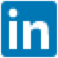

In [7]:
!curl 'https://www.linkedin.com/oauth/v2/authorization?response_type=code&client_id=86zg34xat4tf8b&redirect_uri=https://example.com/callback&scope=r_liteprofile%20r_emailaddress%20w_member_social'


In [8]:
import requests

def get_access_token(auth_code, client_id, client_secret, redirect_uri):
    url = "https://www.linkedin.com/oauth/v2/accessToken"
    params = {
        "grant_type": "authorization_code",
        "code": auth_code,
        "redirect_uri": redirect_uri,
        "client_id": client_id,
        "client_secret": client_secret
    }

    response = requests.post(url, data=params)

    if response.status_code == 200:
        return response.json().get("access_token")
    else:
        print(f"Error: {response.status_code} - {response.text}")
        return None

# Example usage
auth_code = input("Enter the authorization code from the URL: ")  # Manually input the code
client_id = "YOUR_CLIENT_ID"  # Replace with your Client ID
client_secret = "YOUR_CLIENT_SECRET"  # Replace with your Client Secret
redirect_uri = "YOUR_REDIRECT_URI"  # Replace with your Redirect URI

user_token = get_access_token(auth_code, client_id, client_secret, redirect_uri)
if user_token:
    print(f"User Token (Access Token): {user_token}")

Enter the authorization code from the URL:  


Error: 400 - {"error":"invalid_request","error_description":"A required parameter \"code\" is missing"}


In [9]:
https://www.linkedin.com/oauth/v2/authorization?response_type=code&client_id=YOUR_CLIENT_ID&redirect_uri=YOUR_REDIRECT_URI&scope=r_emailaddress%20w_member_social

SyntaxError: invalid decimal literal (3048285098.py, line 1)

In [ ]:
https://www.linkedin.com/oauth/v2/authorization?response_type=code&client_id=86zg34xat4tf8b&redirect_uri=https://example.com/callback&scope=r_emailaddress%20w_member_social

In [4]:

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import time

# Set up the WebDriver
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))

# Navigate to the LinkedIn search results page
url = "https://www.linkedin.com/search/results/people/?geoUrn=%5B%22105763813%22%5D&network=%5B%22S%22%5D&origin=FACETED_SEARCH&pastCompany=%5B%221028%22%5D&profileLanguage=%5B%22en%22%5D&sid=67b&titleFreeText=Director%20OR%20Chief%20OR%20President%20OR%20Principal%20OR%20Partner%20OR%20VP"
driver.get(url)

# Wait for the page to load
time.sleep(5)  # Adjust the sleep time as necessary

# Example: Scrape names from the search results
names = driver.find_elements(By.CSS_SELECTOR, 'span.actor-name')  # Adjust the selector as needed
for name in names:
    print(name.text)

# Close the WebDriver
driver.quit()

In [3]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
import time

# Set up Chrome options for headless mode
chrome_options = Options()
# chrome_options.add_argument("--headless")  # Run in headless mode
chrome_options.add_argument("--no-sandbox")  # Bypass OS security model
chrome_options.add_argument("--disable-dev-shm-usage")  # Overcome limited resource problems

# Set up the WebDriver
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=chrome_options)

# Navigate to LinkedIn login page
driver.get("https://www.linkedin.com/login")

# Wait for the page to load
# time.sleep(2)  # Adjust as necessary

# # Enter your LinkedIn credentials
# email_input = driver.find_element(By.ID, "username")
# password_input = driver.find_element(By.ID, "password")

# email_input.send_keys("lou@louspringer.com")  # Replace with your LinkedIn email
# password_input.send_keys("hxg!fma6JDA6rgt9fdw")  # Replace with your LinkedIn password

# # Click the login button
# login_button = driver.find_element(By.XPATH, "//button[@type='submit']")
# login_button.click()



In [4]:
def analyze_mutual_connections(driver):
    """Find and count mutual connections with multiple approaches"""
    import re
    
    results = {
        "text_matches": [],
        "link_matches": [],
        "count_indicators": [],
        "possible_sections": []
    }
    
    # Look for text patterns
    patterns = [
        "//span[contains(text(), 'mutual connection')]",
        "//a[contains(text(), 'mutual connection')]",
        "//div[contains(text(), 'mutual connection')]",
        "//span[contains(text(), 'connections in common')]",
        "//a[contains(text(), 'connections in common')]"
    ]
    
    for pattern in patterns:
        try:
            elements = driver.find_elements(By.XPATH, pattern)
            for elem in elements:
                results["text_matches"].append({
                    "text": elem.text,
                    "tag": elem.tag_name,
                    "location": elem.location
                })
        except Exception as e:
            print(f"Error with pattern {pattern}: {str(e)}")
            
    # Look for numeric patterns
    number_pattern = r'\d+\s*(?:mutual connection|connection in common)'
    for match in results["text_matches"]:
        if re.search(number_pattern, match["text"], re.IGNORECASE):
            results["count_indicators"].append(match)
    
    print("\nFindings:")
    for category, items in results.items():
        print(f"\n{category.replace('_', ' ').title()}:")
        for item in items:
            print(f"- {item['text']} ({item['tag']})")
            
    return results

# Run it
findings = analyze_mutual_connections(driver)


Findings:

Text Matches:

Link Matches:

Count Indicators:

Possible Sections:


In [9]:
def analyze_mutual_connections(driver):
    """Find and count mutual connections with multiple approaches"""
    import time
    
    # Wait for page load
    time.sleep(3)
    
    # More specific selectors
    patterns = [
        "//span[contains(@class, 'mutual')]",
        "//a[contains(@class, 'mutual')]",
        "//div[contains(@class, 'mutual')]",
        "//span[contains(text(), 'mutual')]",
        "//a[contains(text(), 'mutual')]",
        "//div[contains(text(), 'mutual')]"
    ]
    
    for pattern in patterns:
        try:
            elements = driver.find_elements(By.XPATH, pattern)
            if elements:
                print(f"\nFound with pattern {pattern}:")
                for elem in elements:
                    print(f"Text: {elem.text}")
                    print(f"HTML: {elem.get_attribute('outerHTML')}")
        except Exception as e:
            print(f"Error with {pattern}: {str(e)}")
            continue
            
    return None

# Try again with new approach
analyze_mutual_connections(driver)


In [24]:
# Check if driver is still active and on the right page
print("Current URL:", driver.current_url)
print("Page source length:", len(driver.page_source))

Current URL: https://www.linkedin.com/search/results/people/?facetConnectionOf=%22ACoAAAAR8-0BFGNPdWJ0GwWGIBa65XYTW1fHgsc%22&facetNetwork=%22F%22&origin=MEMBER_PROFILE_CANNED_SEARCH&sid=qM%40
Page source length: 1234994


In [10]:

def analyze_profile_structure(driver):
    """Find and count mutual connections with multiple approaches"""
    import re
    import time
    from selenium.webdriver.support.ui import WebDriverWait
    from selenium.webdriver.support import expected_conditions as EC
    
    # First, let's see what we're actually dealing with
    print("\nPage Analysis:")
    print("-------------")
    print("1. Current URL:", driver.current_url)
    print("2. Page Title:", driver.title)
    
    # Look at all elements with numbers (might catch "XX mutual connections")
    number_elements = driver.find_elements(By.XPATH, "//*[contains(text(), '0') or contains(text(), '1') or contains(text(), '2')]")
    
    print("\nElements containing numbers:")
    for elem in number_elements:
        try:
            if elem.is_displayed():
                print(f"\nText: {elem.text}")
                print(f"Tag: {elem.tag_name}")
                print(f"Classes: {elem.get_attribute('class')}")
                print(f"Parent: {elem.find_element(By.XPATH, '..').tag_name}")
        except:
            continue
            
    # Let's also look at all links - mutual connections might be clickable
    links = driver.find_elements(By.TAG_NAME, "a")
    print("\nAll links:")
    for link in links:
        try:
            if link.is_displayed():
                href = link.get_attribute('href')
                if href and ('mutual' in href.lower() or 'connection' in href.lower()):
                    print(f"\nLink text: {link.text}")
                    print(f"HREF: {href}")
        except:
            continue

# Run our forensic analysis
analyze_profile_structure(driver)



Page Analysis:
-------------
1. Current URL: https://www.linkedin.com/in/tracyshintaku/
2. Page Title: Tracy (Tracy Sofia) Shintaku | LinkedIn

Elements containing numbers:

Text: 500+
Tag: span
Classes: t-bold
Parent: span

Text: 1,926 followers
Tag: span
Classes: 
Parent: p

Text: 1,926 followers
Tag: span
Classes: visually-hidden
Parent: p

Text:  • 1st
Tag: span
Classes: 
Parent: span

Text:  • 1st
Tag: span
Classes: visually-hidden
Parent: span

Text: 2mo • 
 
Tag: span
Classes: 
Parent: span

Text:  • 1st
Tag: span
Classes: 
Parent: span

Text:  • 1st
Tag: span
Classes: visually-hidden
Parent: span

Text: 10 yrs 10 mos
Tag: span
Classes: 
Parent: span

Text: 10 yrs 10 mos
Tag: span
Classes: visually-hidden
Parent: span

Text: Jul 2018 - Present · 6 yrs 7 mos
Tag: span
Classes: pvs-entity__caption-wrapper
Parent: span

Text: Jul 2018 to Present · 6 yrs 7 mos
Tag: span
Classes: visually-hidden
Parent: span

Text: Apr 2014 - Jul 2018 · 4 yrs 4 mos
Tag: span
Classes: pvs-entity__cap

In [11]:
def get_mutual_connections(driver):
    """Get mutual connections count from profile"""
    links = driver.find_elements(By.TAG_NAME, "a")
    for link in links:
        try:
            if link.is_displayed():
                text = link.text
                if "mutual connections" in text.lower():
                    names = text.split("and")[0].strip().split(", ")
                    others = int(text.split("and")[1].split()[0])
                    return {
                        "shown_names": names,
                        "other_count": others,
                        "total_count": len(names) + others
                    }
        except:
            continue
    return None

In [12]:
get_mutual_connections(driver)

{'shown_names': ['Vito Foderaro', 'Jefre Futch,'],
 'other_count': 124,
 'total_count': 126}

In [14]:
def extract_connection_profiles():
    """Extract profiles from mutual connections listing page"""
    import time
    from selenium.webdriver.common.by import By
    
    # Wait for dynamic content
    time.sleep(2)
    
    connections = []
    
    # Try multiple possible selectors since LinkedIn changes them often
    selectors = [
        "//span[contains(@class, 'entity-result__title-text')]//a",
        "//div[contains(@class, 'entity-result__item')]//a[contains(@class, 'app-aware-link')]",
        "//ul[contains(@class, 'reusable-search__entity-result-list')]//a[contains(@href, '/in/')]"
    ]
    
    for selector in selectors:
        try:
            elements = driver.find_elements(By.XPATH, selector)
            for elem in elements:
                if elem.is_displayed():
                    href = elem.get_attribute('href')
                    if href and '/in/' in href:  # Verify it's a profile URL
                        name = elem.text.strip()
                        if name:  # Only add if we got a name
                            connections.append({
                                'name': name,
                                'url': href.split('?')[0]  # Remove URL parameters
                            })
            if connections:  # If we found profiles, break the loop
                break
        except Exception as e:
            print(f"Error with selector {selector}: {str(e)}")
            continue
    
    return connections

# Run it and show results
profiles = extract_connection_profiles()
print(f"\nFound {len(profiles)} profiles:")
for profile in profiles[:5]:  # Show first 5 as sample
    print(f"\nName: {profile['name']}")
    print(f"URL: {profile['url']}")


Found 0 profiles:


In [15]:
def analyze_search_page_structure():
    """Analyze the structure of LinkedIn's search results page"""
    print("\nPage Analysis:")
    print("-------------")
    
    # 1. Look for pagination info
    try:
        pagination = driver.find_elements(By.XPATH, "//*[contains(text(), 'Results') or contains(text(), 'Page')]")
        print("\nPagination elements:")
        for p in pagination:
            if p.is_displayed():
                print(f"Text: {p.text}")
                print(f"Tag: {p.tag_name}")
                print(f"Classes: {p.get_attribute('class')}")
    except Exception as e:
        print(f"Pagination error: {str(e)}")

    # 2. Look for any search result containers
    try:
        results = driver.find_elements(By.XPATH, "//div[contains(@class, 'search-result') or contains(@class, 'entity-result')]")
        print(f"\nFound {len(results)} potential result containers")
        if results:
            sample = results[0]
            print("\nSample result structure:")
            print(f"Classes: {sample.get_attribute('class')}")
            print(f"HTML: {sample.get_attribute('outerHTML')[:200]}...")  # First 200 chars
    except Exception as e:
        print(f"Results error: {str(e)}")

    # 3. Look for profile links
    try:
        links = driver.find_elements(By.TAG_NAME, "a")
        profile_links = [l for l in links if l.is_displayed() and '/in/' in (l.get_attribute('href') or '')]
        print(f"\nFound {len(profile_links)} visible profile links")
        if profile_links:
            print("\nSample profile link:")
            print(f"Text: {profile_links[0].text}")
            print(f"HREF: {profile_links[0].get_attribute('href')}")
    except Exception as e:
        print(f"Links error: {str(e)}")

# Let's see what we're working with
analyze_search_page_structure()


Page Analysis:
-------------

Pagination elements:

Found 25 potential result containers

Sample result structure:
Classes: search-results-container
HTML: <div class="search-results-container">
              
    

        
    <div id="tw94F4AGSVuIKnmBgIu/KQ==">
        <div class="
            pv0 ph0 mb2 artdeco-card">
<!---->
<!---->
               ...

Found 42 visible profile links

Sample profile link:
Text: Status is online
HREF: https://www.linkedin.com/in/tonykay?miniProfileUrn=urn%3Ali%3Afs_miniProfile%3AACoAAAAaUr8BLAarDDFXsYREtDW1IW417wvnMCg


In [16]:
def extract_search_results():
    """Extract profiles from search results page"""
    import time
    from selenium.webdriver.common.by import By
    
    profiles = []
    
    # Look for the main container first
    containers = driver.find_elements(By.CLASS_NAME, "search-results-container")
    if containers:
        # Find all profile cards within the container
        cards = driver.find_elements(By.XPATH, "//div[contains(@class, 'artdeco-card')]")
        
        for card in cards:
            try:
                # Find the primary profile link
                links = card.find_elements(By.XPATH, ".//a[contains(@href, '/in/')]")
                for link in links:
                    href = link.get_attribute('href')
                    if href and '/in/' in href:
                        # Clean the URL to just the profile path
                        base_url = href.split('?')[0]
                        # Try to get the name - might be in different elements
                        name = link.get_attribute('aria-label') or link.text
                        
                        if base_url and name and not "Status is online" in name:
                            profiles.append({
                                'name': name.strip(),
                                'url': base_url,
                                'raw_url': href  # Keep the full URL just in case
                            })
                            break  # Found the main profile link, move to next card
            except Exception as e:
                print(f"Error processing card: {str(e)}")
                continue
    
    # Remove duplicates while preserving order
    seen = set()
    unique_profiles = []
    for p in profiles:
        if p['url'] not in seen:
            seen.add(p['url'])
            unique_profiles.append(p)
    
    return unique_profiles

# Run it
results = extract_search_results()
print(f"\nFound {len(results)} unique profiles:")
for profile in results[:5]:  # Show first 5 as sample
    print(f"\nName: {profile['name']}")
    print(f"URL: {profile['url']}")
    


Found 1 unique profiles:

Name: Tony Kay
View Tony Kay’s profile
URL: https://www.linkedin.com/in/tonykay


In [17]:
def debug_search_page():
    """Detailed debug of search results structure"""
    print("\nDEBUG SEARCH PAGE STRUCTURE:")
    print("-" * 50)
    
    # 1. Look specifically at artdeco-cards
    cards = driver.find_elements(By.CLASS_NAME, "artdeco-card")
    print(f"\n1. Found {len(cards)} artdeco-cards")
    if cards:
        print("\nFirst card classes:", cards[0].get_attribute('class'))
        print("First card text:", cards[0].text[:200])
    
    # 2. Look for search-result elements
    results = driver.find_elements(By.CLASS_NAME, "entity-result")
    print(f"\n2. Found {len(results)} entity-results")
    if results:
        print("\nFirst result classes:", results[0].get_attribute('class'))
        print("First result text:", results[0].text[:200])
    
    # 3. Look for name elements specifically
    names = driver.find_elements(By.CLASS_NAME, "entity-result__title-text")
    print(f"\n3. Found {len(names)} title-text elements")
    if names:
        print("\nFirst name element classes:", names[0].get_attribute('class'))
        print("First name text:", names[0].text[:200])
    
    # 4. Raw profile links
    links = driver.find_elements(By.XPATH, "//a[contains(@href, '/in/')]")
    print(f"\n4. Found {len(links)} profile links")
    if links:
        for i, link in enumerate(links[:3]):  # Show first 3
            print(f"\nLink {i+1}:")
            print("Text:", link.text)
            print("HREF:", link.get_attribute('href'))
            print("Classes:", link.get_attribute('class'))

# Run debug
debug_search_page()


DEBUG SEARCH PAGE STRUCTURE:
--------------------------------------------------

1. Found 5 artdeco-cards

First card classes: 
            pv0 ph0 mb2 artdeco-card
First card text: Status is online
Tony Kay
View Tony Kay’s profile
• 1st
1st degree connection
Senior Principal Architect at Red Hat
Boulder, CO
Mikael Loefstrand, John J. McLaughlin, and 66 other mutual connections
M

2. Found 0 entity-results

3. Found 0 title-text elements

4. Found 56 profile links

Link 1:
Text: Status is online
HREF: https://www.linkedin.com/in/tonykay?miniProfileUrn=urn%3Ali%3Afs_miniProfile%3AACoAAAAaUr8BLAarDDFXsYREtDW1IW417wvnMCg
Classes: yuTiyfThjbmJEkOhrygcPqcsypqUauKnsvux  scale-down 

Link 2:
Text: Tony Kay
View Tony Kay’s profile
HREF: https://www.linkedin.com/in/tonykay?miniProfileUrn=urn%3Ali%3Afs_miniProfile%3AACoAAAAaUr8BLAarDDFXsYREtDW1IW417wvnMCg
Classes: yuTiyfThjbmJEkOhrygcPqcsypqUauKnsvux 

Link 3:
Text: Mikael Loefstrand
HREF: https://www.linkedin.com/in/ACoAAAAB6_8B46V8SO2E4RYj-Tu

In [18]:
def extract_search_profiles():
    """Extract profiles from search results using the actual page structure"""
    profiles = []
    seen_urls = set()
    
    # Get all artdeco-cards (these are the profile containers)
    cards = driver.find_elements(By.CLASS_NAME, "artdeco-card")
    
    for card in cards:
        try:
            # Get all text to help filter
            card_text = card.text
            
            # Skip if it's empty or not a profile card
            if not card_text or len(card_text) < 10:
                continue
                
            # Get all profile links in this card
            links = card.find_elements(By.XPATH, ".//a[contains(@href, '/in/')]")
            
            for link in links:
                href = link.get_attribute('href')
                text = link.text.strip()
                
                # Skip status links and empty text
                if not text or text == "Status is online":
                    continue
                    
                # Clean the URL
                base_url = href.split('?')[0] if href else None
                
                # Skip if we've seen this URL or it's invalid
                if not base_url or base_url in seen_urls:
                    continue
                    
                # Extract name and details
                name = text.split('\n')[0] if '\n' in text else text
                
                profiles.append({
                    'name': name,
                    'url': base_url,
                    'raw_url': href,
                    'full_text': text
                })
                seen_urls.add(base_url)
                
                # Break after finding main profile link (to avoid duplicates)
                break
                
        except Exception as e:
            print(f"Error processing card: {str(e)}")
            continue
    
    return profiles

# Run it
results = extract_search_profiles()
print(f"\nFound {len(results)} unique profiles:")
for profile in results:
    print(f"\nName: {profile['name']}")
    print(f"URL: {profile['url']}")
    print(f"Full text: {profile['full_text'][:100]}...")  # Show first 100 chars of full text


Found 1 unique profiles:

Name: Tony Kay
URL: https://www.linkedin.com/in/tonykay
Full text: Tony Kay
View Tony Kay’s profile...


In [19]:
def extract_search_profiles_v2():
    """Extract profiles using structural patterns rather than class names"""
    import time
    profiles = []
    seen_urls = set()
    
    # Look for any div containing both a profile link and connection info
    xpath_patterns = [
        # Pattern 1: Find elements with '/in/' links that have text
        "//a[contains(@href, '/in/') and string-length(text()) > 0]",
        
        # Pattern 2: Find elements with profile URNs
        "//a[contains(@href, 'miniProfileUrn')]",
        
        # Pattern 3: Find elements with both href and aria-label
        "//a[@href and @aria-label and contains(@href, '/in/')]"
    ]
    
    for pattern in xpath_patterns:
        elements = driver.find_elements(By.XPATH, pattern)
        
        for elem in elements:
            try:
                href = elem.get_attribute('href')
                if not href:
                    continue
                    
                # Clean the URL
                base_url = href.split('?')[0]
                if not base_url or base_url in seen_urls:
                    continue
                
                # Get text content
                text = elem.text.strip()
                aria_label = elem.get_attribute('aria-label')
                
                # Skip status indicators and empty elements
                if text in ['Status is online', ''] or not (text or aria_label):
                    continue
                
                # Use the most informative text source
                name = text.split('\n')[0] if '\n' in text else text
                if not name and aria_label:
                    name = aria_label
                
                profiles.append({
                    'name': name,
                    'url': base_url,
                    'raw_url': href,
                    'text': text,
                    'aria_label': aria_label
                })
                seen_urls.add(base_url)
                
            except Exception as e:
                print(f"Error processing element: {str(e)}")
                continue
    
    # Remove duplicates while preserving order
    unique_profiles = []
    seen = set()
    for p in profiles:
        if p['url'] not in seen:
            seen.add(p['url'])
            unique_profiles.append(p)
    
    return unique_profiles

# Run it
results = extract_search_profiles_v2()
print(f"\nFound {len(results)} unique profiles:")
for profile in results[:10]:  # Show first 10
    print(f"\nName: {profile['name']}")
    print(f"URL: {profile['url']}")


Found 19 unique profiles:

Name: Tony Kay
URL: https://www.linkedin.com/in/tonykay

Name: Status is reachable
URL: https://www.linkedin.com/in/billwalker4

Name: Ken Pepple
URL: https://www.linkedin.com/in/kenpepple

Name: Status is reachable
URL: https://www.linkedin.com/in/chrishause

Name: Status is reachable
URL: https://www.linkedin.com/in/bpilarski

Name: Status is reachable
URL: https://www.linkedin.com/in/esglover

Name: Status is reachable
URL: https://www.linkedin.com/in/alecmuffett

Name: Status is reachable
URL: https://www.linkedin.com/in/arif-khan-ak

Name: Status is reachable
URL: https://www.linkedin.com/in/roy-pillay-bb493b

Name: Status is reachable
URL: https://www.linkedin.com/in/ecophil


In [22]:
from datetime import datetime
import pytz
from selenium.webdriver.common.by import By

def extract_search_profiles_v5():
    """Extract profiles with their online status and timestamp"""
    profiles = []
    seen_urls = set()
    
    # Get current time in UTC
    timestamp = datetime.now(pytz.UTC)
    
    # Find all profile cards
    cards = driver.find_elements(By.XPATH, "//div[.//a[contains(@href, '/in/')]]")
    
    for card in cards:
        try:
            links = card.find_elements(By.XPATH, ".//a[contains(@href, '/in/')]")
            card_text = card.text.split('\n')
            
            profile_data = {
                'timestamp_utc': timestamp,
                'timestamp_iso': timestamp.isoformat()
            }
            
            for link in links:
                href = link.get_attribute('href')
                if not href:
                    continue
                
                base_url = href.split('?')[0]
                text = link.text.strip()
                
                # Capture online status with timestamp
                if 'Status is' in text:
                    profile_data['online_status'] = text
                # Capture name and URL
                elif text and not 'View' in text and not base_url in seen_urls:
                    profile_data['name'] = text
                    profile_data['url'] = base_url
                    seen_urls.add(base_url)
            
            # Only add if we have both name and URL
            if 'name' in profile_data and 'url' in profile_data:
                # Get position/location if available
                for line in card_text:
                    if '• ' in line:
                        profile_data['details'] = line
                        break
                
                profiles.append(profile_data)
                
        except Exception as e:
            continue
    
    return profiles

# Run it with proper imports
results = extract_search_profiles_v5()
print(f"\nFound {len(results)} profiles at {datetime.now().isoformat()}:")
for profile in results[:5]:  # Show first 5
    print("\nProfile:")
    for key, value in profile.items():
        print(f"{key}: {value}")


Found 1 profiles at 2025-01-13T14:42:19.065481:

Profile:
timestamp_utc: 2025-01-13 21:41:58.728727+00:00
timestamp_iso: 2025-01-13T21:41:58.728727+00:00
online_status: Status is reachable
name: Jefre Futch
url: https://www.linkedin.com/in/ACoAAAAeqwgBjNyRQGWKZoaVMfmkvhghRwNKJ7I
details: • 1st


In [23]:
def extract_search_profiles_v6():
    """Extract profiles with their online status and timestamp"""
    from datetime import datetime
    import pytz
    
    profiles = []
    seen_urls = set()
    timestamp = datetime.now(pytz.UTC)
    
    # Try different card selectors
    selectors = [
        "//li[contains(@class, 'reusable-search__result-container')]",  # Common pattern
        "//div[contains(@class, 'search-results__cluster-content')]//div",  # Another pattern
        "//div[contains(@class, 'entity-result__item')]"  # Backup pattern
    ]
    
    for selector in selectors:
        try:
            cards = driver.find_elements(By.XPATH, selector)
            print(f"Found {len(cards)} cards with selector: {selector}")  # Debug info
            
            for card in cards:
                try:
                    card_html = card.get_attribute('outerHTML')
                    print(f"\nCard HTML preview: {card_html[:200]}")  # Debug info
                    
                    links = card.find_elements(By.XPATH, ".//a[contains(@href, '/in/')]")
                    card_text = card.text.split('\n')
                    
                    profile_data = {
                        'timestamp_utc': timestamp,
                        'timestamp_iso': timestamp.isoformat()
                    }
                    
                    for link in links:
                        href = link.get_attribute('href')
                        if not href:
                            continue
                        
                        text = link.text.strip()
                        
                        if 'Status is' in text:
                            profile_data['online_status'] = text
                        elif text and not 'View' in text:
                            profile_data['name'] = text
                            profile_data['url'] = href
                    
                    if 'name' in profile_data and 'url' in profile_data:
                        for line in card_text:
                            if '• ' in line:
                                profile_data['details'] = line
                                break
                        
                        profiles.append(profile_data)
                        
                except Exception as e:
                    print(f"Error processing card: {str(e)}")  # Debug info
                    continue
                    
            if profiles:  # If we found profiles with this selector, stop trying others
                break
                
        except Exception as e:
            print(f"Error with selector {selector}: {str(e)}")  # Debug info
            continue
    
    return profiles

# Run it with debug info
results = extract_search_profiles_v6()
print(f"\nFound {len(results)} profiles at {datetime.now().isoformat()}:")
for profile in results[:5]:
    print("\nProfile:")
    for key, value in profile.items():
        print(f"{key}: {value}")

Found 0 cards with selector: //li[contains(@class, 'reusable-search__result-container')]
Found 0 cards with selector: //div[contains(@class, 'search-results__cluster-content')]//div
Found 0 cards with selector: //div[contains(@class, 'entity-result__item')]

Found 0 profiles at 2025-01-13T14:43:39.267365:


In [25]:
def analyze_linkedin_page(page_type="UNKNOWN"):
    """
    Wrapper for linkedin_autopsy that logs the context
    
    Args:
        page_type: String identifying what type of page we're analyzing
    """
    from datetime import datetime
    
    print(f"\n\nANALYZING {page_type} PAGE @ {datetime.now().isoformat()}")
    print("=" * 50)
    print(f"Current URL: {driver.current_url}")
    
    def linkedin_autopsy():
        """Forensic analysis of LinkedIn's current page structure"""
        print("\n🔍 FORENSIC ANALYSIS")
        print("===================")
        
        # 1. All divs with any content
        print("\n1. Looking for ANY div with profile-like content...")
        divs = driver.find_elements(By.XPATH, "//div[contains(text(), '•') or contains(text(), 'connections')]")
        print(f"Found {len(divs)} suspicious divs")
        if divs:
            print("\nSample div contents:")
            for div in divs[:3]:
                print(f"\n{div.text[:200]}")
        
        # 2. All links that might be profiles
        print("\n2. Scanning for profile-like links...")
        links = driver.find_elements(By.XPATH, "//a[contains(@href, '/in/') or contains(@href, 'miniProfile')]")
        print(f"Found {len(links)} potential profile links")
        if links:
            print("\nSample links:")
            for link in links[:3]:
                print(f"\nText: {link.text}")
                print(f"HREF: {link.get_attribute('href')}")
        
        # 3. Page source analysis
        print("\n3. Analyzing page structure...")
        key_terms = ['entity-result', 'search-result', 'artdeco', 'profile']
        for term in key_terms:
            count = driver.page_source.count(term)
            print(f"Found '{term}' {count} times in source")
        
        # 4. Current URL check
        print("\n4. Current location:")
        print(f"URL: {driver.current_url}")
        
        # 5. Visible text scan
        print("\n5. Visible text patterns:")
        text_elements = driver.find_elements(By.XPATH, "//*[text()]")
        patterns = {
            'status': 0,
            'connection': 0,
            'profile': 0,
            'degree': 0,
            'mutual': 0
        }
        for elem in text_elements:
            try:
                text = elem.text.lower()
                for pattern in patterns:
                    if pattern in text:
                        patterns[pattern] += 1
            except:
                continue
        
        print("\nText pattern frequencies:")
        for pattern, count in patterns.items():
            print(f"{pattern}: {count}")
    
    # Run the autopsy
    linkedin_autopsy()

# Run it on the current listing page
analyze_linkedin_page("MUTUAL CONNECTIONS LISTING")



ANALYZING MUTUAL CONNECTIONS LISTING PAGE @ 2025-01-13T14:48:54.780350
Current URL: https://www.linkedin.com/search/results/people/?facetConnectionOf=%22ACoAAAAR8-0BFGNPdWJ0GwWGIBa65XYTW1fHgsc%22&facetNetwork=%22F%22&origin=MEMBER_PROFILE_CANNED_SEARCH&sid=qM%40

🔍 FORENSIC ANALYSIS

1. Looking for ANY div with profile-like content...
Found 0 suspicious divs

2. Scanning for profile-like links...
Found 56 potential profile links

Sample links:

Text: Status is online
HREF: https://www.linkedin.com/in/tonykay?miniProfileUrn=urn%3Ali%3Afs_miniProfile%3AACoAAAAaUr8BLAarDDFXsYREtDW1IW417wvnMCg

Text: Tony Kay
View Tony Kay’s profile
HREF: https://www.linkedin.com/in/tonykay?miniProfileUrn=urn%3Ali%3Afs_miniProfile%3AACoAAAAaUr8BLAarDDFXsYREtDW1IW417wvnMCg

Text: Mikael Loefstrand
HREF: https://www.linkedin.com/in/ACoAAAAB6_8B46V8SO2E4RYj-TuThEwhtmST41A?miniProfileUrn=urn%3Ali%3Afs_miniProfile%3AACoAAAAB6_8B46V8SO2E4RYj-TuThEwhtmST41A

3. Analyzing page structure...
Found 'entity-result' 

In [26]:
def extract_profiles_from_listing():
    """Extract profiles using the patterns we found"""
    from datetime import datetime
    import pytz
    
    profiles = []
    timestamp = datetime.now(pytz.UTC)
    
    # Look for entity-result containers
    containers = driver.find_elements(By.XPATH, "//*[contains(@class, 'entity-result')]")
    
    for container in containers:
        try:
            profile_data = {
                'timestamp_utc': timestamp,
                'timestamp_iso': timestamp.isoformat()
            }
            
            # Get all links in this container
            links = container.find_elements(By.XPATH, ".//a[contains(@href, '/in/')]")
            
            for link in links:
                href = link.get_attribute('href')
                text = link.text.strip()
                
                if 'Status is' in text:
                    profile_data['online_status'] = text
                elif text and not 'View' in text:
                    profile_data['name'] = text
                    profile_data['url'] = href.split('?')[0]
                    profile_data['mini_profile_urn'] = href.split('miniProfileUrn=')[1] if 'miniProfileUrn=' in href else None
            
            if 'name' in profile_data:
                profiles.append(profile_data)
                
        except Exception as e:
            continue
    
    return profiles

# Try the new targeted approach
results = extract_profiles_from_listing()
print(f"\nFound {len(results)} profiles:")
for profile in results[:5]:  # Show first 5
    print("\nProfile:")
    for key, value in profile.items():
        print(f"{key}: {value}")


Found 10 profiles:

Profile:
timestamp_utc: 2025-01-13 21:50:11.426302+00:00
timestamp_iso: 2025-01-13T21:50:11.426302+00:00
name: John J. McLaughlin
url: https://www.linkedin.com/in/ACoAAAADfVsBobdT3ag2t3wrp56I1-w89ZvKuKA
mini_profile_urn: urn%3Ali%3Afs_miniProfile%3AACoAAAADfVsBobdT3ag2t3wrp56I1-w89ZvKuKA

Profile:
timestamp_utc: 2025-01-13 21:50:11.426302+00:00
timestamp_iso: 2025-01-13T21:50:11.426302+00:00
name: Dawn C Simmons (Khan)
url: https://www.linkedin.com/in/ACoAAAAAcfMBchWkm1iwYTsUyQi2KrzjPtfXnS0
mini_profile_urn: urn%3Ali%3Afs_miniProfile%3AACoAAAAAcfMBchWkm1iwYTsUyQi2KrzjPtfXnS0

Profile:
timestamp_utc: 2025-01-13 21:50:11.426302+00:00
timestamp_iso: 2025-01-13T21:50:11.426302+00:00
name: John J. McLaughlin
url: https://www.linkedin.com/in/ACoAAAADfVsBobdT3ag2t3wrp56I1-w89ZvKuKA
mini_profile_urn: urn%3Ali%3Afs_miniProfile%3AACoAAAADfVsBobdT3ag2t3wrp56I1-w89ZvKuKA

Profile:
timestamp_utc: 2025-01-13 21:50:11.426302+00:00
timestamp_iso: 2025-01-13T21:50:11.426302+00:00
n

In [27]:
def scrape_all_mutual_connections():
    """Get all mutual connections across multiple pages"""
    all_profiles = []
    page = 1
    
    while True:
        print(f"\nProcessing page {page}...")
        
        # Get current page profiles
        current_profiles = extract_profiles_from_listing()
        all_profiles.extend(current_profiles)
        
        print(f"Found {len(current_profiles)} profiles on this page")
        print(f"Total profiles so far: {len(all_profiles)}")
        
        # Try to find next page button
        try:
            next_button = driver.find_element(By.XPATH, "//button[contains(@aria-label, 'Next')]")
            if next_button.is_enabled():
                next_button.click()
                time.sleep(2)  # Give it time to load
                page += 1
            else:
                print("Next button disabled - reached last page")
                break
        except:
            print("No next button found - reached last page")
            break
    
    return all_profiles

# Let's get them all!
all_results = scrape_all_mutual_connections()


Processing page 1...
Found 10 profiles on this page
Total profiles so far: 10
No next button found - reached last page


In [28]:
def analyze_pagination():
    """Analyze the pagination controls"""
    print("\nPAGINATION ANALYSIS:")
    print("===================")
    
    # 1. Look for any buttons
    buttons = driver.find_elements(By.TAG_NAME, "button")
    print(f"\nFound {len(buttons)} buttons:")
    for button in buttons[:5]:  # Show first 5
        try:
            print(f"\nText: {button.text}")
            print(f"Aria-Label: {button.get_attribute('aria-label')}")
            print(f"Classes: {button.get_attribute('class')}")
            print(f"Enabled: {button.is_enabled()}")
        except:
            continue
            
    # 2. Look for pagination containers
    print("\nLooking for pagination containers:")
    patterns = [
        "//div[contains(@class, 'pagination')]",
        "//div[contains(@class, 'page')]",
        "//ul[contains(@class, 'pagination')]",
        "//div[contains(@class, 'artdeco-pagination')]"
    ]
    
    for pattern in patterns:
        elements = driver.find_elements(By.XPATH, pattern)
        print(f"\nPattern '{pattern}':")
        print(f"Found {len(elements)} elements")
        if elements:
            print("Sample HTML:", elements[0].get_attribute('outerHTML')[:200])
            
    # 3. Look for page numbers in text
    print("\nLooking for page indicators:")
    page_texts = driver.find_elements(By.XPATH, "//*[contains(text(), 'Page') or contains(text(), 'of')]")
    for elem in page_texts:
        if elem.is_displayed():
            print(f"Text: {elem.text}")

# Let's see what we're working with
analyze_pagination()


PAGINATION ANALYSIS:

Found 83 buttons:

Text: 
Aria-Label: None
Classes: mr4 artdeco-button artdeco-button--muted artdeco-button--2 artdeco-button--secondary ember-view
Enabled: True

Text: 
Aria-Label: None
Classes: artdeco-button artdeco-button--muted artdeco-button--2 artdeco-button--secondary ember-view
Enabled: True

Text: 
Aria-Label: None
Classes: artdeco-button artdeco-button--muted artdeco-button--2 artdeco-button--secondary ember-view ml4
Enabled: True

Text: 
Aria-Label: None
Classes: global-nav__a11y-menu-close artdeco-button artdeco-button--circle artdeco-button--muted artdeco-button--2 artdeco-button--tertiary ember-view
Enabled: True

Text: 
Aria-Label: Click to start a search
Classes: search-global-typeahead__collapsed-search-button
Enabled: True

Looking for pagination containers:

Pattern '//div[contains(@class, 'pagination')]':
Found 2 elements
Sample HTML: <div id="ember581" class="artdeco-pagination artdeco-pagination--has-controls ember-view pv5 ph2">  <span cla

In [29]:
def scrape_all_mutual_connections():
    """Get all mutual connections across multiple pages"""
    from time import sleep
    all_profiles = []
    page = 1
    
    while True:
        print(f"\nProcessing page {page} of 13...")
        
        # Get current page profiles
        current_profiles = extract_profiles_from_listing()
        all_profiles.extend(current_profiles)
        
        print(f"Found {len(current_profiles)} profiles on this page")
        print(f"Total profiles so far: {len(all_profiles)}")
        
        # Look for next button using the actual structure
        try:
            # Find the pagination container
            pagination = driver.find_element(By.CLASS_NAME, "artdeco-pagination")
            
            # Find all page buttons
            buttons = pagination.find_elements(By.XPATH, ".//button")
            
            # Look for the next button (usually last button)
            next_button = None
            for button in buttons:
                if 'next' in (button.get_attribute('aria-label') or '').lower():
                    next_button = button
                    break
            
            if next_button and next_button.is_enabled():
                next_button.click()
                sleep(2)  # Give it time to load
                page += 1
            else:
                print("Next button not found or disabled - reached last page")
                break
                
        except Exception as e:
            print(f"Pagination error: {str(e)}")
            break
    
    print(f"\nFinished! Collected {len(all_profiles)} total profiles")
    return all_profiles

# Let's get all 13 pages!
all_results = scrape_all_mutual_connections()


Processing page 1 of 13...
Found 10 profiles on this page
Total profiles so far: 10
Pagination error: Message: element click intercepted: Element <button aria-label="Next" id="ember602" class="artdeco-button artdeco-button--muted artdeco-button--icon-right artdeco-button--1 artdeco-button--tertiary ember-view artdeco-pagination__button artdeco-pagination__button--next" type="button">...</button> is not clickable at point (791, 856). Other element would receive the click: <h2 class="pr1 msg-overlay-bubble-header__title truncate t-14 t-bold
                t-black
                pl1
                " tabindex="-1">...</h2>
  (Session info: chrome=131.0.6778.265)
Stacktrace:
0   chromedriver                        0x000000010f562ab8 chromedriver + 7092920
1   chromedriver                        0x000000010f55a39a chromedriver + 7058330
2   chromedriver                        0x000000010ef00d70 chromedriver + 400752
3   chromedriver                        0x000000010ef56906 chromedriver 

In [30]:
def scrape_all_mutual_connections():
    """Get all mutual connections across multiple pages"""
    from time import sleep
    from selenium.webdriver.common.by import By
    from selenium.webdriver.common.action_chains import ActionChains
    from selenium.webdriver.support.ui import WebDriverWait
    from selenium.webdriver.support import expected_conditions as EC
    
    all_profiles = []
    page = 1
    
    while True:
        print(f"\nProcessing page {page} of 13...")
        
        # Get current page profiles
        current_profiles = extract_profiles_from_listing()
        all_profiles.extend(current_profiles)
        
        print(f"Found {len(current_profiles)} profiles on this page")
        print(f"Total profiles so far: {len(all_profiles)}")
        
        try:
            # Find the pagination container
            pagination = driver.find_element(By.CLASS_NAME, "artdeco-pagination")
            
            # Try to close any message overlays
            try:
                msg_close_button = driver.find_element(By.CLASS_NAME, "msg-overlay-bubble-header__button")
                msg_close_button.click()
                sleep(1)
            except:
                print("No message overlay found or couldn't close it")
            
            # Find and scroll to the next button
            next_button = WebDriverWait(driver, 10).until(
                EC.presence_of_element_located((By.XPATH, "//button[contains(@aria-label, 'Next')]"))
            )
            
            # Scroll into view
            driver.execute_script("arguments[0].scrollIntoView(true);", next_button)
            sleep(1)  # Let the scroll complete
            
            # Try to click using JavaScript if regular click fails
            if next_button.is_enabled():
                try:
                    next_button.click()
                except:
                    driver.execute_script("arguments[0].click();", next_button)
                sleep(2)
                page += 1
            else:
                print("Next button disabled - reached last page")
                break
                
        except Exception as e:
            print(f"Pagination error: {str(e)}")
            break
    
    print(f"\nFinished! Collected {len(all_profiles)} total profiles")
    return all_profiles

# Let's try again with overlay handling
all_results = scrape_all_mutual_connections()


Processing page 1 of 13...
Found 10 profiles on this page
Total profiles so far: 10

Processing page 2 of 13...
Found 10 profiles on this page
Total profiles so far: 20

Processing page 3 of 13...
Found 10 profiles on this page
Total profiles so far: 30

Processing page 4 of 13...
Found 10 profiles on this page
Total profiles so far: 40

Processing page 5 of 13...
Found 10 profiles on this page
Total profiles so far: 50

Processing page 6 of 13...
Found 10 profiles on this page
Total profiles so far: 60

Processing page 7 of 13...
Found 10 profiles on this page
Total profiles so far: 70

Processing page 8 of 13...
Found 10 profiles on this page
Total profiles so far: 80

Processing page 9 of 13...
Found 10 profiles on this page
Total profiles so far: 90

Processing page 10 of 13...
Found 10 profiles on this page
Total profiles so far: 100

Processing page 11 of 13...
Found 10 profiles on this page
Total profiles so far: 110

Processing page 12 of 13...
Found 10 profiles on this page
T

In [31]:
all_results

[{'timestamp_utc': datetime.datetime(2025, 1, 13, 21, 58, 47, 906244, tzinfo=<UTC>),
  'timestamp_iso': '2025-01-13T21:58:47.906244+00:00',
  'name': 'John J. McLaughlin',
  'url': 'https://www.linkedin.com/in/ACoAAAADfVsBobdT3ag2t3wrp56I1-w89ZvKuKA',
  'mini_profile_urn': 'urn%3Ali%3Afs_miniProfile%3AACoAAAADfVsBobdT3ag2t3wrp56I1-w89ZvKuKA'},
 {'timestamp_utc': datetime.datetime(2025, 1, 13, 21, 58, 47, 906244, tzinfo=<UTC>),
  'timestamp_iso': '2025-01-13T21:58:47.906244+00:00',
  'name': 'Dawn C Simmons (Khan)',
  'url': 'https://www.linkedin.com/in/ACoAAAAAcfMBchWkm1iwYTsUyQi2KrzjPtfXnS0',
  'mini_profile_urn': 'urn%3Ali%3Afs_miniProfile%3AACoAAAAAcfMBchWkm1iwYTsUyQi2KrzjPtfXnS0'},
 {'timestamp_utc': datetime.datetime(2025, 1, 13, 21, 58, 47, 906244, tzinfo=<UTC>),
  'timestamp_iso': '2025-01-13T21:58:47.906244+00:00',
  'name': 'John J. McLaughlin',
  'url': 'https://www.linkedin.com/in/ACoAAAADfVsBobdT3ag2t3wrp56I1-w89ZvKuKA',
  'mini_profile_urn': 'urn%3Ali%3Afs_miniProfile%3AAC

In [32]:
'# we are here, because we have to be somewhere'

'# we are here, because we have to be somewhere'

In [33]:
# Create a set of unique profiles based on mini_profile_urn
unique_profiles = {profile['mini_profile_urn']: profile for profile in all_results}.values()
unique_profiles = list(unique_profiles)

print(f"Original count: {len(all_results)}")
print(f"After removing duplicates: {len(unique_profiles)}")

# Quick frequency analysis of duplicates
from collections import Counter
name_frequency = Counter(profile['name'] for profile in all_results)
print("\nMost common names (showing top 5):")
for name, count in name_frequency.most_common(5):
    print(f"{name}: {count} occurrences")

Original count: 125
After removing duplicates: 32

Most common names (showing top 5):
John J. McLaughlin: 26 occurrences
Kevin Mullenex: 14 occurrences
Jack Lopez: 13 occurrences
Mikael Loefstrand: 11 occurrences
Nick Chang: 11 occurrences


In [34]:
# Basic pattern analysis
unique_names = set(profile['name'] for profile in unique_profiles)
print(f"\nUnique individuals: {len(unique_names)}")

# Look for any service providers (profiles with "Provides services" in name)
service_providers = [p for p in unique_profiles if p['name'].startswith('Provides services')]
print(f"\nService providers found: {len(service_providers)}")

# Timestamp analysis
timestamps = [p['timestamp_utc'] for p in unique_profiles]
earliest = min(timestamps)
latest = max(timestamps)
print(f"\nData collection period:")
print(f"Started: {earliest}")
print(f"Ended: {latest}")
print(f"Duration: {latest - earliest}")


Unique individuals: 32

Service providers found: 2

Data collection period:
Started: 2025-01-13 21:58:47.906244+00:00
Ended: 2025-01-13 21:59:51.938950+00:00
Duration: 0:01:04.032706


In [35]:
# Domain Analysis - What companies/organizations are represented?
domains = Counter([url.split('/')[2] for profile in unique_profiles for url in [profile['url']]])

# Service Provider Analysis - What services are most commonly offered?
service_types = []
for profile in service_providers:
    services = profile['name'].split('-')[1].split(',')
    service_types.extend([s.strip() for s in services])
service_frequency = Counter(service_types)

# Connection Clustering
# - Group profiles by timestamp to see if there are "batches" of connections
# - Could indicate different departments or organizational units

# URL Pattern Analysis
# Look for patterns in the profile URNs - might indicate join date or other metadata
urn_patterns = [p['mini_profile_urn'].split(':')[-1][:10] for p in unique_profiles]

In [36]:
urn_patterns

['urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3',
 'urn%3Ali%3']

In [37]:
# Extract the actual unique identifiers from URNs
profile_ids = [p['mini_profile_urn'].split('ACoAA')[-1] for p in unique_profiles]

# Look for patterns in ID lengths and character distributions
id_lengths = Counter([len(id) for id in profile_ids])
print("\nProfile ID length distribution:")
for length, count in id_lengths.most_common():
    print(f"Length {length}: {count} profiles")

# Analyze first few characters to look for batching/grouping patterns
prefix_patterns = Counter([id[:4] for id in profile_ids])
print("\nMost common ID prefixes:")
for prefix, count in prefix_patterns.most_common(5):
    print(f"Prefix {prefix}: {count} profiles")

# Time-based grouping
from collections import defaultdict
time_groups = defaultdict(list)
for p in unique_profiles:
    timestamp = p['timestamp_utc'].strftime('%H:%M')  # Group by minute
    time_groups[timestamp].append(p['name'])

print("\nProfile collection timing:")
for time, names in sorted(time_groups.items()):
    print(f"{time}: {len(names)} profiles")


Profile ID length distribution:
Length 34: 32 profiles

Most common ID prefixes:
Prefix AAJW: 2 profiles
Prefix AADf: 1 profiles
Prefix AAAc: 1 profiles
Prefix AAB6: 1 profiles
Prefix AAGa: 1 profiles

Profile collection timing:
21:58: 4 profiles
21:59: 28 profiles


In [2]:

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=chrome_options)

In [5]:
driver.close()


In [7]:

# Now navigate to the LinkedIn search results page
# url = "https://www.linkedin.com/search/results/people/?geoUrn=%5B%22105763813%22%5D&network=%5B%22S%22%5D&origin=FACETED_SEARCH&pastCompany=%5B%221028%22%5D&profileLanguage=%5B%22en%22%5D&sid=67b&titleFreeText=Director%20OR%20Chief%20OR%20President%20OR%20Principal%20OR%20Partner%20OR%20VP"
url = "https://www.linkedin.com/in/jefrefutch/"
driver.get(url)

# Wait for the page to load
# driver.implicitly_wait(10)  # Use implicit wait instead of sleep

# # Example: Scrape names from the search results
# names = driver.find_elements(By.CSS_SELECTOR, 'span.actor-name')  # Adjust the selector as needed
# for name in names:
#     print(name.text)

# Close the WebDriver
# driver.quit()

In [9]:
driver.__dict__


{'service': <selenium.webdriver.chrome.service.Service at 0x110cf5030>,
 'command_executor': <selenium.webdriver.chromium.remote_connection.ChromiumRemoteConnection at 0x110d0dc00>,
 '_is_remote': False,
 'session_id': '8300564f7ec45553956725d8314f2708',
 'caps': {'acceptInsecureCerts': False,
  'browserName': 'chrome',
  'browserVersion': '131.0.6778.265',
  'chrome': {'chromedriverVersion': '131.0.6778.264 (2d05e31515360f4da764174f7c448b33e36da871-refs/branch-heads/6778@{#4323})',
   'userDataDir': '/var/folders/hg/zvfs15m17550vl6qnf_q010w0000gn/T/.org.chromium.Chromium.BcG6f6'},
  'fedcm:accounts': True,
  'goog:chromeOptions': {'debuggerAddress': 'localhost:50462'},
  'networkConnectionEnabled': False,
  'pageLoadStrategy': 'normal',
  'platformName': 'mac',
  'proxy': {},
  'setWindowRect': True,
  'strictFileInteractability': False,
  'timeouts': {'implicit': 0, 'pageLoad': 300000, 'script': 30000},
  'unhandledPromptBehavior': 'dismiss and notify',
  'webauthn:extension:credBlob

In [10]:
help(driver)

Help on WebDriver in module selenium.webdriver.chrome.webdriver object:

class WebDriver(selenium.webdriver.chromium.webdriver.ChromiumDriver)
 |  WebDriver(options: selenium.webdriver.chrome.options.Options = None, service: selenium.webdriver.chrome.service.Service = None, keep_alive: bool = True) -> None
 |  
 |  Controls the ChromeDriver and allows you to drive the browser.
 |  
 |  Method resolution order:
 |      WebDriver
 |      selenium.webdriver.chromium.webdriver.ChromiumDriver
 |      selenium.webdriver.remote.webdriver.WebDriver
 |      selenium.webdriver.remote.webdriver.BaseWebDriver
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self, options: selenium.webdriver.chrome.options.Options = None, service: selenium.webdriver.chrome.service.Service = None, keep_alive: bool = True) -> None
 |      Creates a new instance of the chrome driver. Starts the service and
 |      then creates new instance of chrome driver.
 |      
 |      :Args:
 |       - op

In [16]:
driver.get_log('browser')

[{'level': 'WARNING',
  'message': 'https://www.linkedin.com/login 98 <link rel=preload> must have a valid `as` value',
  'source': 'other',
  'timestamp': 1733352269945},
 {'level': 'WARNING',
  'message': 'https://www.linkedin.com/login 99 <link rel=preload> must have a valid `as` value',
  'source': 'other',
  'timestamp': 1733352269945},
 {'level': 'WARNING',
  'message': 'https://www.linkedin.com/login 100 <link rel=preload> must have a valid `as` value',
  'source': 'other',
  'timestamp': 1733352269945},
 {'level': 'WARNING',
  'message': 'https://www.linkedin.com/login 101 <link rel=preload> must have a valid `as` value',
  'source': 'other',
  'timestamp': 1733352269946},
 {'level': 'WARNING',
  'message': 'https://www.linkedin.com/login 104 <link rel=preload> must have a valid `as` value',
  'source': 'other',
  'timestamp': 1733352269946},
 {'level': 'WARNING',
  'message': 'https://www.linkedin.com/login 105 <link rel=preload> must have a valid `as` value',
  'source': 'oth

In [10]:
driver.find_elements()

[]

In [11]:
page_source = driver.page_source()

NoSuchWindowException: Message: no such window: target window already closed
from unknown error: web view not found
  (Session info: chrome=131.0.6778.265)
Stacktrace:
0   chromedriver                        0x000000010e4c9ab8 chromedriver + 7092920
1   chromedriver                        0x000000010e4c139a chromedriver + 7058330
2   chromedriver                        0x000000010de67d70 chromedriver + 400752
3   chromedriver                        0x000000010de3d8af chromedriver + 227503
4   chromedriver                        0x000000010dee349d chromedriver + 906397
5   chromedriver                        0x000000010def9b45 chromedriver + 998213
6   chromedriver                        0x000000010dedafc3 chromedriver + 872387
7   chromedriver                        0x000000010dea95c2 chromedriver + 669122
8   chromedriver                        0x000000010deaa59e chromedriver + 673182
9   chromedriver                        0x000000010e48e350 chromedriver + 6849360
10  chromedriver   